# Code Template for Map

1. one map per figure

## 1. one map per figure

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

In [12]:
# Function to create a colormap from a AR6 text file containing RGB values
def create_colormap_from_txt(filepath, cmap_name="custom_colormap"):
    """
    Read RGB values from a text file and create a LinearSegmentedColormap.
    RGB value shoud be 0-1 range.
    """
    rgb_data = np.loadtxt(filepath)
    colormap = mcolors.LinearSegmentedColormap.from_list(cmap_name, rgb_data)
    return colormap

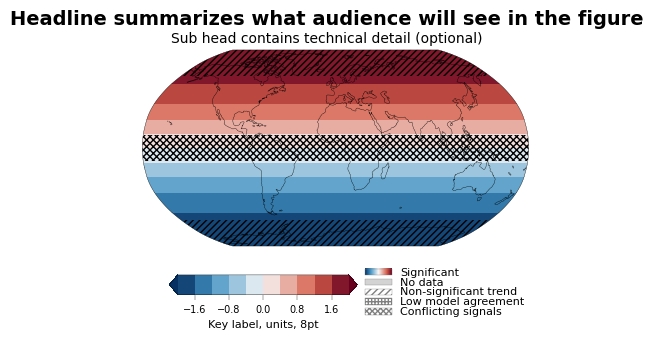

In [42]:
# Dummy data
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
lon2d, lat2d = np.meshgrid(lon, lat)

data = 2 * np.sin(np.deg2rad(lat2d))
levels = np.linspace(-2, 2, 11)

# Dummy significance mask
no_significance = np.abs(lat2d) <10
low_model_agreement = np.abs(lat2d) >60


# Figure layout
# fig = plt.figure(figsize=(6.5, 3.65))
fig = plt.figure(figsize=(7, 3.65)) # maximum width 180mm ~ 7 inches

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[12, 4],  # 12 top row for map, 4 bottom row for colorbar and legend
    width_ratios=[1, 1],
    hspace=0.15,
    wspace=0.02
)

# Headings (format: bold, 14pt, centered)
fig.text(0.5, 0.95,
         "Headline summarizes what audience will see in the figure",
         ha='center',
         fontsize=14,
         fontweight='bold') 

# Sub-headings (format: regular, 10pt, centered)
fig.text(
    0.5, 0.90,
    "Sub head contains technical detail (optional)",
    ha='center',
    fontsize=10,
)

# Fix line/box widths
lw = 0.255 # 0.09mm = 0.255 pt
 
# Map axis
ax = fig.add_subplot(gs[0, :], projection=ccrs.Robinson()) # Robinson projection is IPCC standard for global maps
ax.set_global()
ax.spines['geo'].set_linewidth(lw) # map frame (outline)

cmap = create_colormap_from_txt("./continuous_colormaps_rgb_0-1/temp_div.txt")

 
# Colour layer
im = ax.contourf(
    lon, lat, data,
    levels=levels,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    extend='both',
    zorder=1
)

# Diagonal hatching
ax.contourf(
    lon, lat, no_significance,
    levels=[0.5, 1],
    hatches=['xxxxx'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.contourf(
    lon, lat, low_model_agreement,
    levels=[0.5, 1],
    hatches=['/////'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=2
)

 
# Coastlines
ax.coastlines(linewidth=lw, zorder=5) # linewidth for coastlines

 
# Bottom Left: Colourbar (50%)

# create a custom axis for the colorbar in the bottom left cell of the grid
cax = fig.add_subplot(gs[1, 0])
pos = cax.get_position()  # Bbox: [x0, y0, width, height]

# modify position to make the colorbar thinner and shift right
new_pos = [pos.x0 + 0.15,   # move right
           pos.y0 + 0.1,  # move up slightly
           pos.width * 0.7, # shrink width
           pos.height * 0.3] # reduce height to make it thinner

cax.set_position(new_pos)

# create the colorbar in the custom axis
cbar = plt.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
)

cbar.set_label("Key label, units, 8pt", fontsize=8)

cbar.outline.set_linewidth(lw) # colorbar outline
cbar.ax.tick_params(
    width=lw,        # tick line thickness
    # length=lw * 10,   # tick length (adjust visually)
    labelsize=7
)

# Bottom right (50%): Custom Legend
lax = fig.add_subplot(gs[1, 1])
lax.axis('off')

# Force a stable coordinate system
lax.set_xlim(0, 1)
lax.set_ylim(0, 1)

# Layout
box_w, box_h = 0.1, 0.1 # box width in 2.5mm ~ 0.1 inches
x0 = 0.1
y0 = 0.85
dy = box_h + 0.05
text_x = x0 + box_w + 0.03


# ---- 1. Significant (gradient bar) ----
grad = np.linspace(0, 1, 256).reshape(1, -1)

lax.imshow(
    grad,
    extent=(x0, x0 + box_w, y0, y0 + box_h),
    cmap=cmap,
    aspect='auto',
    transform=lax.transAxes,
    zorder=1
)

# Border
lax.add_patch(mpatches.Rectangle(
    (x0, y0), box_w, box_h,
    transform=lax.transAxes,
    fill=False, edgecolor= 'gray', linewidth=lw, zorder=2
))

lax.text(text_x, y0 + box_h / 2, "Significant",
         transform=lax.transAxes,
         va='center', fontsize=8)

# --- 2. Other legend entries ---
entries = [
    ("No data", dict(facecolor='lightgray', edgecolor='gray')),
    ("Non-significant trend", dict(facecolor='white', edgecolor='gray', hatch='/////')),
    ("Low model agreement", dict(facecolor='white', edgecolor='gray', hatch='+++++')),
    ("Conflicting signals", dict(facecolor='white', edgecolor='gray', hatch='xxxxxx')),
]

for i, (label, style) in enumerate(entries, start=1):
    y = y0 - i * dy

    rect = mpatches.Rectangle(
        (x0, y), box_w, box_h,
        transform=lax.transAxes,
        linewidth=lw,
        **style
    )
    lax.add_patch(rect)

    lax.text(text_x, y + box_h / 2, label,
             transform=lax.transAxes,
             va='center', fontsize=8)

# Prevent autoscale from imshow
lax.set_xlim(0, 1)
lax.set_ylim(0, 1)

 
# Save and show
plt.savefig("./fig_svg/fig_1map.svg", bbox_inches='tight')
plt.show()
plt.close()
